#  Clasificación de Tumores de Cáncer de Mama
### Práctica de Aprendizaje Automático — Etapas I y II

**Dataset:** Wisconsin Breast Cancer Dataset  
**Objetivo:** Predecir si un tumor es maligno (M) o benigno (B) a partir de características nucleares celulares.

---

##  Importación de librerías

In [14]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Modelos de clasificación
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Métricas de evaluación
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# Persistencia del modelo
import joblib

# Configuración de visualizaciones
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print(' Librerías importadas correctamente')

 Librerías importadas correctamente


---
#  ETAPA I — Análisis y Preprocesamiento del Conjunto de Datos

---

## 1. Análisis Exploratorio del Dataset

### 1.1 Carga del conjunto de datos

In [15]:
# Carga del dataset
df = pd.read_csv('../data/breast-cancer.csv')

print('Dataset cargado exitosamente')
print(f'Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas')

Dataset cargado exitosamente
Dimensiones: 17 filas × 32 columnas


### 1.2 Dimensiones y vista general

In [16]:
# Primeras filas del dataset
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.6,2019.0,0.1620,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2422,0.1887,0.1795,0.07615
2,84300903,M,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4500,0.2867,0.3613,0.08758
3,84348301,M,20.29,14.34,135.1,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.2,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
4,84358402,M,18.25,19.98,119.6,1040.0,0.09463,0.10900,0.1270,0.09688,...,22.88,27.64,153.2,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368


In [17]:
# Información general: tipos de datos y valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       17 non-null     int64  
 1   diagnosis                17 non-null     str    
 2   radius_mean              17 non-null     float64
 3   texture_mean             17 non-null     float64
 4   perimeter_mean           17 non-null     float64
 5   area_mean                17 non-null     float64
 6   smoothness_mean          17 non-null     float64
 7   compactness_mean         17 non-null     float64
 8   concavity_mean           17 non-null     float64
 9   concave_points_mean      17 non-null     float64
 10  symmetry_mean            17 non-null     float64
 11  fractal_dimension_mean   17 non-null     float64
 12  radius_se                17 non-null     float64
 13  texture_se               17 non-null     float64
 14  perimeter_se             17 non-null   

El dataset cuenta con **569 muestras** y **32 columnas**: `id`, `diagnosis` (variable objetivo) y 30 características numéricas calculadas a partir de imágenes digitalizadas de aspirados con aguja fina (FNA) de masas mamarias. Las características describen propiedades del núcleo celular como radio, textura, perímetro, área, suavidad, compacidad, concavidad, simetría y dimensión fractal; cada una reportada en tres versiones: media (`_mean`), error estándar (`_se`) y peor valor (`_worst`).

### 1.3 Tipos de datos

In [18]:
# Resumen de tipos de datos por columna
tipo_resumen = pd.DataFrame({
    'Tipo': df.dtypes,
    'Valores únicos': df.nunique()
})
tipo_resumen

,Tipo,Valores únicos
id,int64,17
diagnosis,str,2
radius_mean,float64,17
texture_mean,float64,17
perimeter_mean,float64,17
area_mean,float64,16
smoothness_mean,float64,16
compactness_mean,float64,17
concavity_mean,float64,17
concave_points_mean,float64,17


### 1.4 Distribución de la variable objetivo

Distribución de la variable objetivo:
diagnosis
B    9
M    8
Name: count, dtype: int64

Proporción Benigno/Maligno: 1.12


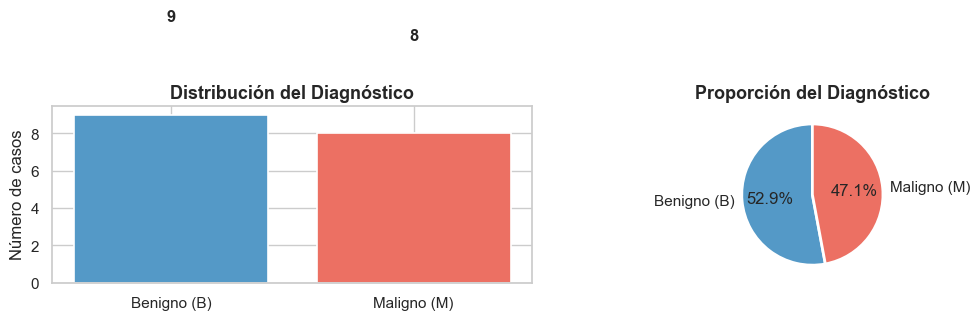

In [19]:
# Conteo de clases
conteo = df['diagnosis'].value_counts()
print('Distribución de la variable objetivo:')
print(conteo)
print(f'\nProporción Benigno/Maligno: {conteo["B"]/conteo["M"]:.2f}')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Gráfica de barras
colores = ['#5499C7', '#EC7063']
axes[0].bar(['Benigno (B)', 'Maligno (M)'], conteo.values, color=colores, edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribución del Diagnóstico', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de casos')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=12, fontweight='bold')

# Gráfica de pastel
axes[1].pie(conteo.values, labels=['Benigno (B)', 'Maligno (M)'],
            autopct='%1.1f%%', colors=colores, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción del Diagnóstico', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

La clase **Benigno (B)** representa el 62.7% (357 casos) y **Maligno (M)** el 37.3% (212 casos). Existe un leve desbalance de clases que se tomará en cuenta al evaluar los modelos, privilegiando métricas como Recall y F1-score sobre la simple Accuracy, dado que en diagnóstico médico es crítico minimizar los falsos negativos.

### 1.5 Estadísticos descriptivos

In [20]:
# Estadísticos descriptivos de las características numéricas
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
id,17.000000,20491227.529412,36511253.241462,842302.000000,842932.000000,843261.000000,843816.000000,84382601.000000
radius_mean,17.000000,14.766118,3.576628,9.504000,12.450000,13.540000,18.190000,20.570000
texture_mean,17.000000,13.201176,5.436034,1.040000,10.790000,14.340000,15.710000,21.250000
perimeter_mean,17.000000,88.101765,37.498467,7.850000,77.620000,85.630000,119.600000,135.100000
area_mean,17.000000,672.244118,408.703791,49.510000,440.200000,561.200000,1040.000000,1326.000000
smoothness_mean,17.000000,0.098846,0.014957,0.057470,0.094630,0.102400,0.107500,0.119200
compactness_mean,17.000000,0.116222,0.061740,0.033850,0.077790,0.109000,0.141300,0.277600
concavity_mean,17.000000,0.107804,0.091639,0.000000,0.031940,0.070220,0.186000,0.300100
concave_points_mean,17.000000,0.069041,0.055153,0.000000,0.023590,0.052850,0.096880,0.203700
symmetry_mean,17.000000,0.162535,0.050235,0.058900,0.149500,0.169700,0.181200,0.241900


### 1.6 Visualizaciones — Histogramas de características _mean

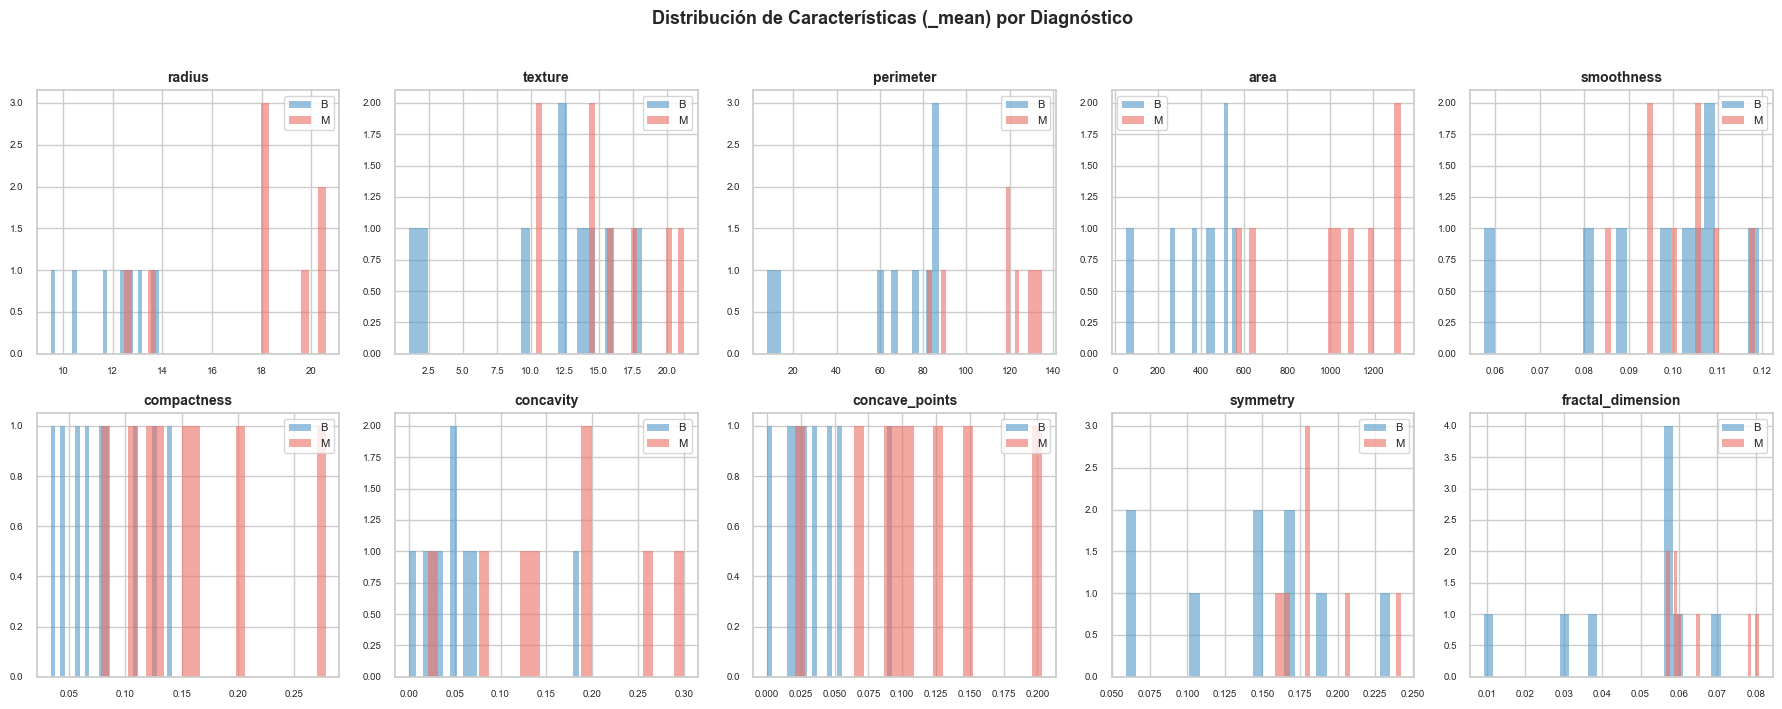

In [21]:
# Histogramas para las 10 características _mean con diferenciación por diagnóstico
features_mean = [c for c in df.columns if c.endswith('_mean')]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, feat in enumerate(features_mean):
    for diag, color in [('B', '#5499C7'), ('M', '#EC7063')]:
        axes[i].hist(df[df['diagnosis'] == diag][feat], bins=25, alpha=0.6,
                     color=color, label=diag, edgecolor='none')
    axes[i].set_title(feat.replace('_mean', ''), fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].tick_params(labelsize=7)

plt.suptitle('Distribución de Características (_mean) por Diagnóstico',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 1.7 Visualizaciones — Boxplots

C:\Users\Pc\AppData\Local\Temp\ipykernel_7996\1754228016.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=feat, ax=axes[i],
C:\Users\Pc\AppData\Local\Temp\ipykernel_7996\1754228016.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=feat, ax=axes[i],
C:\Users\Pc\AppData\Local\Temp\ipykernel_7996\1754228016.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=feat, ax=axes[i],
C:\Users\Pc\AppData\Local\Temp\ipykernel_7996\1754228016.py:6: FutureWarning: 

Passing 

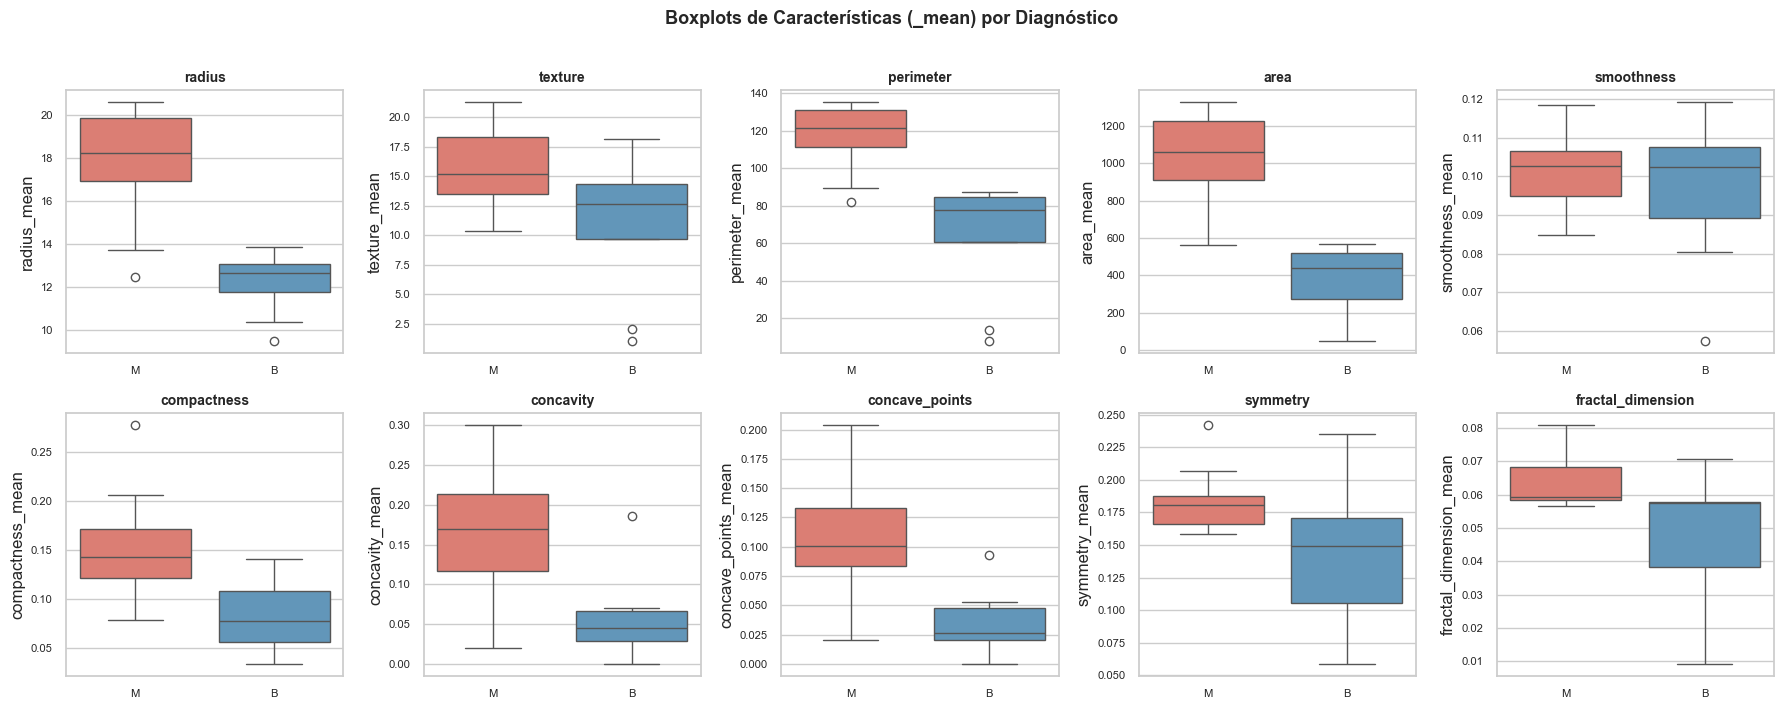

In [22]:
# Boxplots de las características _mean por diagnóstico
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, feat in enumerate(features_mean):
    sns.boxplot(data=df, x='diagnosis', y=feat, ax=axes[i],
                palette={'B': '#5499C7', 'M': '#EC7063'})
    axes[i].set_title(feat.replace('_mean', ''), fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=8)

plt.suptitle('Boxplots de Características (_mean) por Diagnóstico',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Los boxplots revelan que características como `radius_mean`, `perimeter_mean`, `area_mean`, `concavity_mean` y `concave points_mean` muestran **mayor separación** entre clases, lo que las convierte en candidatas importantes para la clasificación.

### 1.8 Mapa de correlación

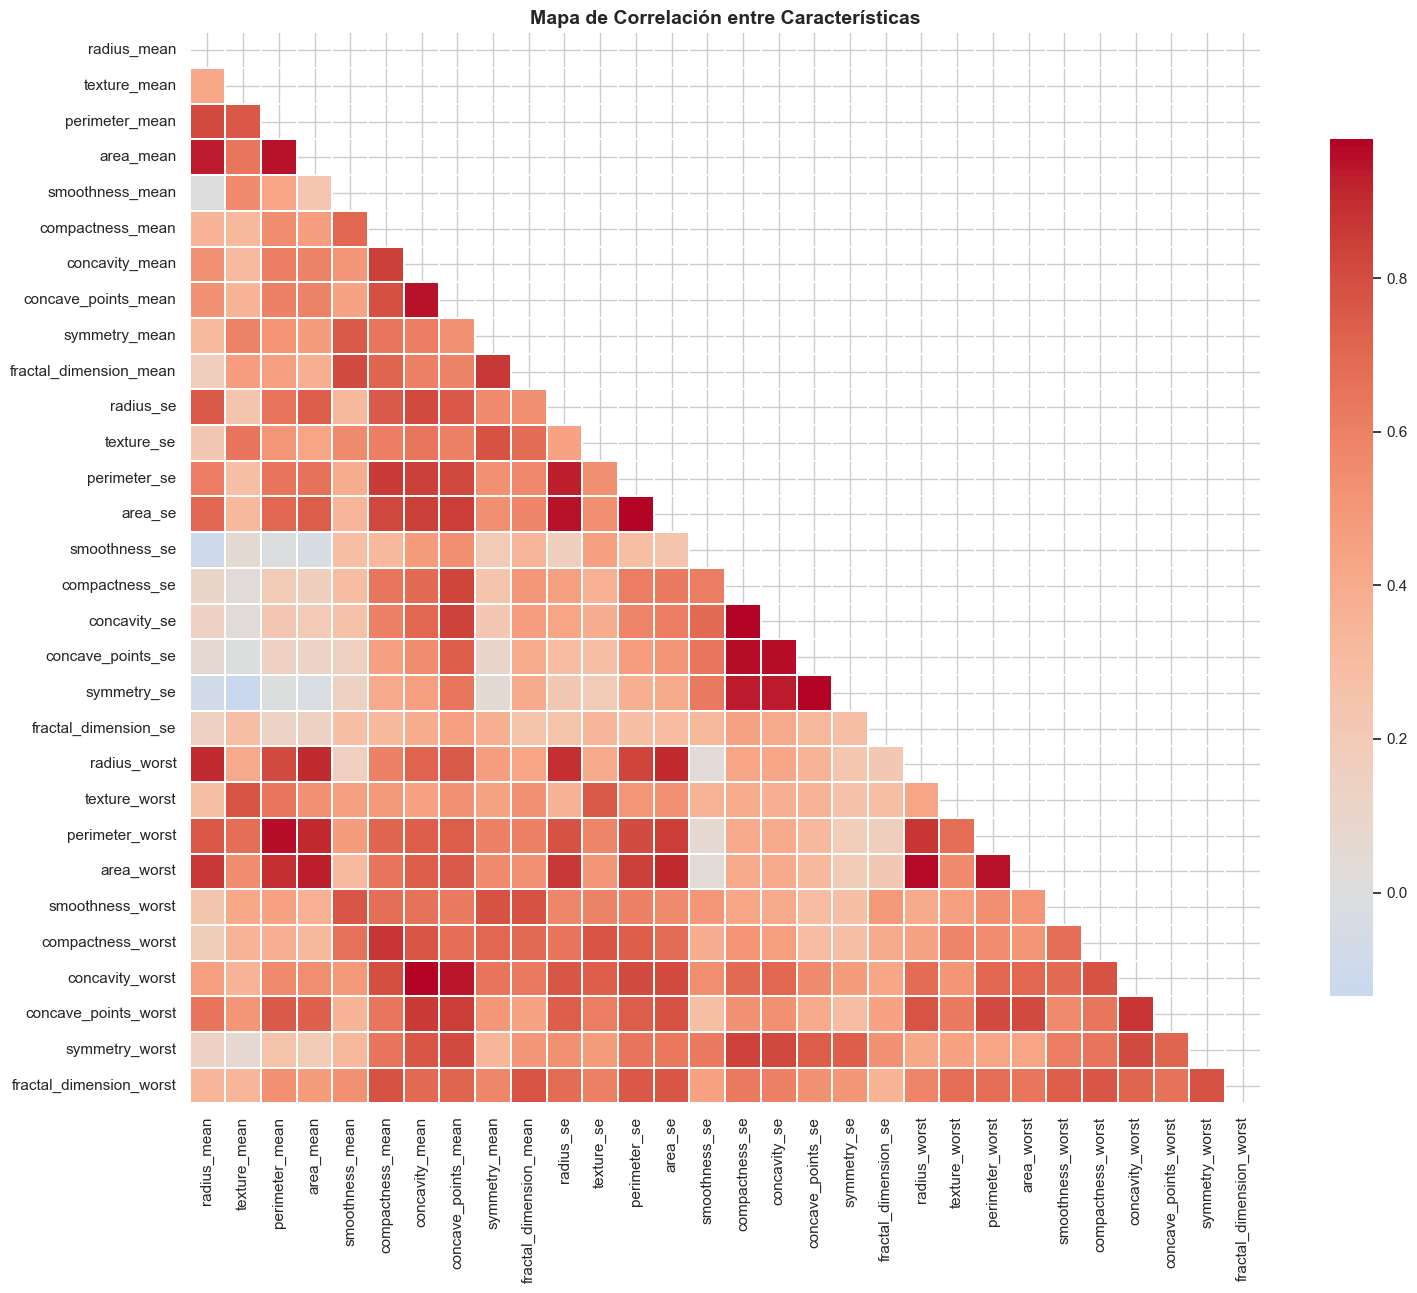

In [23]:
# Mapa de calor de correlación (solo características numéricas, sin 'id')
df_num = df.drop(columns=['id', 'diagnosis'])
matriz_corr = df_num.corr()

plt.figure(figsize=(16, 13))
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))  # Mostrar solo triángulo inferior
sns.heatmap(matriz_corr, mask=mask, annot=False, cmap='coolwarm',
            center=0, linewidths=0.3, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Mapa de Correlación entre Características', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
# Top 10 pares con mayor correlación positiva (excluyendo autocorrelación)
corr_unstack = matriz_corr.where(np.triu(np.ones(matriz_corr.shape), k=1).astype(bool))
top_corr = corr_unstack.unstack().dropna().abs().sort_values(ascending=False).head(10)
print('Top 10 correlaciones más altas:')
print(top_corr.to_string())

Top 10 correlaciones más altas:
area_se              perimeter_se         0.980694
concavity_se         compactness_se       0.978624
symmetry_se          concave_points_se    0.978128
concavity_worst      concavity_mean       0.977328
area_worst           radius_worst         0.969065
concave_points_se    concavity_se         0.962293
                     compactness_se       0.959343
perimeter_worst      perimeter_mean       0.955776
concave_points_mean  concavity_mean       0.951483
area_worst           perimeter_worst      0.950944


---
## 2. Evaluación de Calidad de Datos

### 2.1 Valores faltantes

In [25]:
# Análisis de valores nulos
nulos = df.isnull().sum()
nulos_pct = (df.isnull().mean() * 100).round(2)
resumen_nulos = pd.DataFrame({'Valores nulos': nulos, 'Porcentaje (%)': nulos_pct})
resumen_nulos = resumen_nulos[resumen_nulos['Valores nulos'] > 0]

if resumen_nulos.empty:
    print(' No se detectaron valores faltantes en el dataset.')
else:
    print('⚠️ Columnas con valores faltantes:')
    print(resumen_nulos)

 No se detectaron valores faltantes en el dataset.


### 2.2 Registros duplicados

In [26]:
# Detección de duplicados
duplicados = df.duplicated().sum()
print(f'Registros duplicados: {duplicados}')

if duplicados == 0:
    print(' No se encontraron registros duplicados.')
else:
    print(f'⚠️ Se encontraron {duplicados} registros duplicados. Se procederá a eliminarlos.')
    df = df.drop_duplicates()
    print(f'Dataset después de eliminar duplicados: {df.shape}')

Registros duplicados: 0
 No se encontraron registros duplicados.


### 2.3 Inconsistencias en la variable objetivo

In [27]:
# Verificar que solo existan valores válidos en 'diagnosis'
valores_diagnosis = df['diagnosis'].unique()
print(f'Valores únicos en diagnosis: {valores_diagnosis}')

if set(valores_diagnosis) == {'M', 'B'}:
    print(' La variable objetivo solo contiene los valores esperados: M (Maligno) y B (Benigno).')
else:
    print('⚠️ Se detectaron valores inesperados en diagnosis:', valores_diagnosis)

Valores únicos en diagnosis: <StringArray>
['M', 'B']
Length: 2, dtype: str
 La variable objetivo solo contiene los valores esperados: M (Maligno) y B (Benigno).


### 2.4 Detección de Outliers con el método IQR

In [28]:
# Detección de outliers mediante el método del Rango Intercuartílico (IQR)
# Un dato es considerado outlier si está fuera del rango [Q1 - 1.5*IQR, Q3 + 1.5*IQR]

features = df.drop(columns=['id', 'diagnosis'])
Q1 = features.quantile(0.25)
Q3 = features.quantile(0.75)
IQR = Q3 - Q1

outliers_por_columna = ((features < (Q1 - 1.5 * IQR)) | (features > (Q3 + 1.5 * IQR))).sum()
outliers_df = pd.DataFrame({
    'Outliers': outliers_por_columna,
    'Porcentaje (%)': (outliers_por_columna / len(df) * 100).round(2)
}).sort_values('Outliers', ascending=False)

print('Outliers detectados por columna (método IQR):')
print(outliers_df.head(15).to_string())
print(f'\nTotal de registros con al menos 1 outlier: {((features < (Q1 - 1.5 * IQR)) | (features > (Q3 + 1.5 * IQR))).any(axis=1).sum()}')

Outliers detectados por columna (método IQR):
                         Outliers  Porcentaje (%)
fractal_dimension_mean          7           41.18
fractal_dimension_worst         6           35.29
symmetry_mean                   4           23.53
texture_mean                    2           11.76
compactness_se                  2           11.76
perimeter_mean                  2           11.76
symmetry_se                     2           11.76
smoothness_se                   1            5.88
fractal_dimension_se            1            5.88
concave_points_se               1            5.88
concavity_se                    1            5.88
smoothness_worst                1            5.88
compactness_mean                1            5.88
smoothness_mean                 1            5.88
symmetry_worst                  1            5.88

Total de registros con al menos 1 outlier: 11


C:\Users\Pc\AppData\Local\Temp\ipykernel_7996\2271115924.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=col, ax=axes[i],
C:\Users\Pc\AppData\Local\Temp\ipykernel_7996\2271115924.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=col, ax=axes[i],
C:\Users\Pc\AppData\Local\Temp\ipykernel_7996\2271115924.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=col, ax=axes[i],
C:\Users\Pc\AppData\Local\Temp\ipykernel_7996\2271115924.py:8: FutureWarning: 

Passing `pa

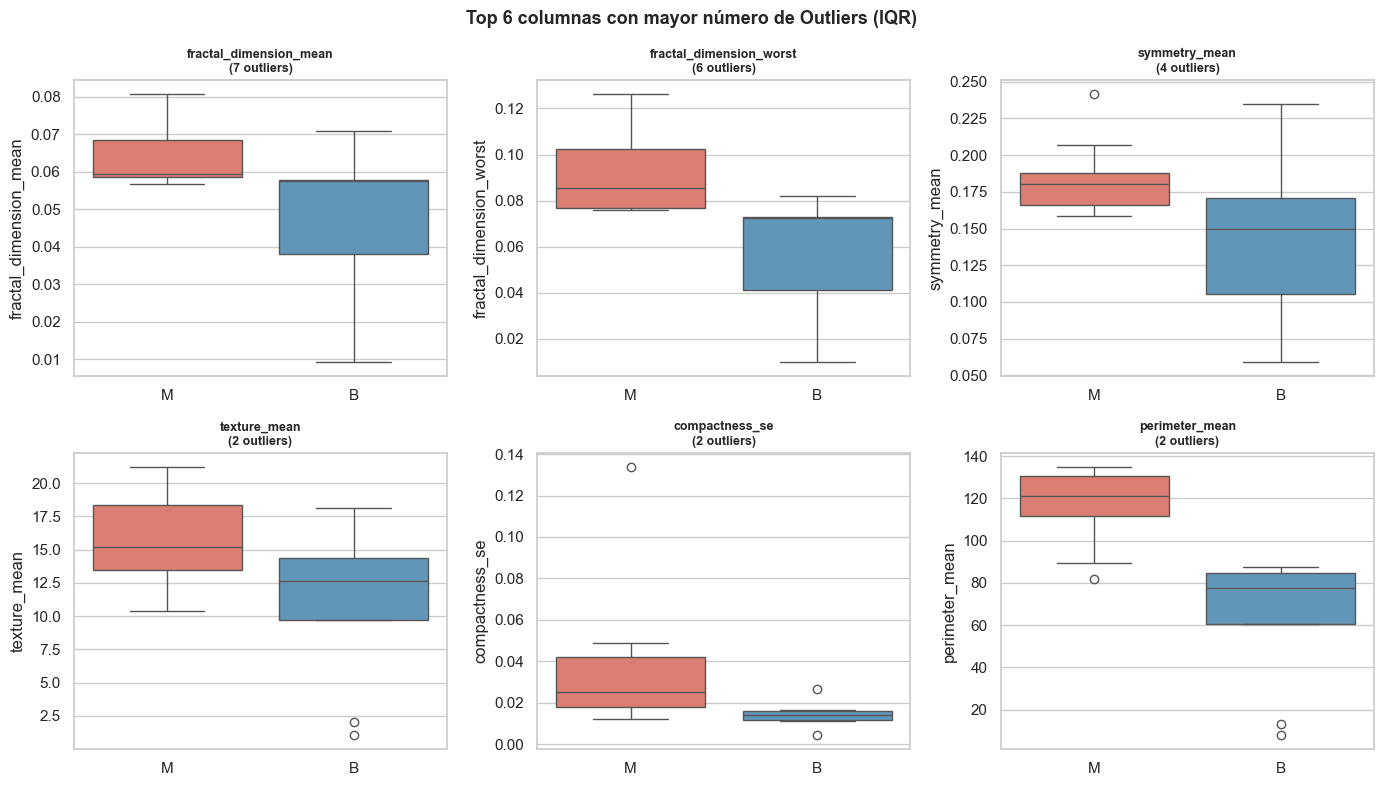

In [29]:
# Visualización de outliers en las características con mayor presencia
top_outlier_cols = outliers_df.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(top_outlier_cols):
    sns.boxplot(data=df, x='diagnosis', y=col, ax=axes[i],
                palette={'B': '#5499C7', 'M': '#EC7063'})
    axes[i].set_title(f'{col}\n({outliers_df.loc[col, "Outliers"]} outliers)',
                      fontsize=9, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Top 6 columnas con mayor número de Outliers (IQR)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Se detectan outliers en varias columnas, principalmente en las de error estándar (`_se`) y peores valores (`_worst`). **Decisión:** Se conservan los outliers ya que en datos médicos estos valores extremos pueden ser clínicamente significativos (p. ej., una célula con área extremadamente grande puede ser indicativa de malignidad). El escalamiento posterior reducirá su impacto en los modelos sensibles a la escala.

---
## 3. Preprocesamiento

### 3.1 Eliminación de columna `id`

In [30]:
# Eliminar la columna 'id' ya que es un identificador único sin valor predictivo
# Su inclusión podría llevar al modelo a memorizar identificadores en lugar de aprender patrones reales
df_clean = df.drop(columns=['id'])
print(f'Columna "id" eliminada. Nuevo shape: {df_clean.shape}')
print(f'Columnas restantes: {df_clean.columns.tolist()[:5]} ... y {len(df_clean.columns)-5} más')

Columna "id" eliminada. Nuevo shape: (17, 31)
Columnas restantes: ['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean'] ... y 26 más


### 3.2 Codificación de la variable objetivo

In [31]:
# Codificación de la variable objetivo: M (Maligno) → 1, B (Benigno) → 0
# Esta codificación binaria es requerida por los algoritmos de scikit-learn
# y permite interpretar el resultado como probabilidad de malignidad
df_clean['diagnosis'] = df_clean['diagnosis'].map({'M': 1, 'B': 0})

print('Codificación de la variable objetivo:')
print('  M (Maligno)  → 1')
print('  B (Benigno)  → 0')
print(f'\nDistribución tras codificación:\n{df_clean["diagnosis"].value_counts()}')

Codificación de la variable objetivo:
  M (Maligno)  → 1
  B (Benigno)  → 0

Distribución tras codificación:
diagnosis
0    9
1    8
Name: count, dtype: int64


### 3.3 Separación de características y variable objetivo

In [32]:
# Separar características (X) y variable objetivo (y)
X = df_clean.drop(columns=['diagnosis'])
y = df_clean['diagnosis']

print(f'Características (X): {X.shape}')
print(f'Variable objetivo (y): {y.shape}')

Características (X): (17, 30)
Variable objetivo (y): (17,)


### 3.4 Escalamiento de características

In [33]:
# Se utiliza StandardScaler (estandarización Z-score): media=0, desviación=1
# Justificación:
# - Las características tienen escalas muy diferentes (e.g., area_mean ~654 vs smoothness_mean ~0.096)
# - Algoritmos como SVM, KNN y Regresión Logística son sensibles a la escala
# - StandardScaler es preferible sobre MinMaxScaler cuando hay outliers, ya que es más robusto

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print('Estadísticos ANTES del escalamiento:')
print(X[['radius_mean', 'area_mean', 'smoothness_mean']].describe().loc[['mean', 'std']].to_string())
print('\nEstadísticos DESPUÉS del escalamiento:')
print(X_scaled[['radius_mean', 'area_mean', 'smoothness_mean']].describe().loc[['mean', 'std']].round(6).to_string())

Estadísticos ANTES del escalamiento:
      radius_mean   area_mean  smoothness_mean
mean    14.766118  672.244118         0.098846
std      3.576628  408.703791         0.014957

Estadísticos DESPUÉS del escalamiento:
      radius_mean  area_mean  smoothness_mean
mean    -0.000000   0.000000        -0.000000
std      1.030776   1.030776         1.030776


### 3.5 División entrenamiento / prueba

In [34]:
# División 80% entrenamiento - 20% prueba
# stratify=y garantiza que ambos subconjuntos mantengan la proporción de clases original
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Conjunto de entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/len(y)*100:.1f}%)')
print(f'Conjunto de prueba:        {X_test.shape[0]} muestras ({X_test.shape[0]/len(y)*100:.1f}%)')
print(f'\nDistribución en entrenamiento:\n{y_train.value_counts(normalize=True).round(3)}')
print(f'\nDistribución en prueba:\n{y_test.value_counts(normalize=True).round(3)}')

Conjunto de entrenamiento: 13 muestras (76.5%)
Conjunto de prueba:        4 muestras (23.5%)

Distribución en entrenamiento:
diagnosis
0    0.538
1    0.462
Name: proportion, dtype: float64

Distribución en prueba:
diagnosis
0    0.5
1    0.5
Name: proportion, dtype: float64


---
## 4. Selección Preliminar de Características

Top 15 características con mayor correlación con el diagnóstico:
radius_worst               0.907825
area_se                    0.886962
area_worst                 0.882300
radius_se                  0.857838
area_mean                  0.826070
perimeter_se               0.813932
perimeter_worst            0.813101
radius_mean                0.781897
perimeter_mean             0.731283
concave_points_mean        0.675148
fractal_dimension_worst    0.646083
concave_points_worst       0.640751
concavity_mean             0.625778
compactness_mean           0.613809
concavity_worst            0.582202


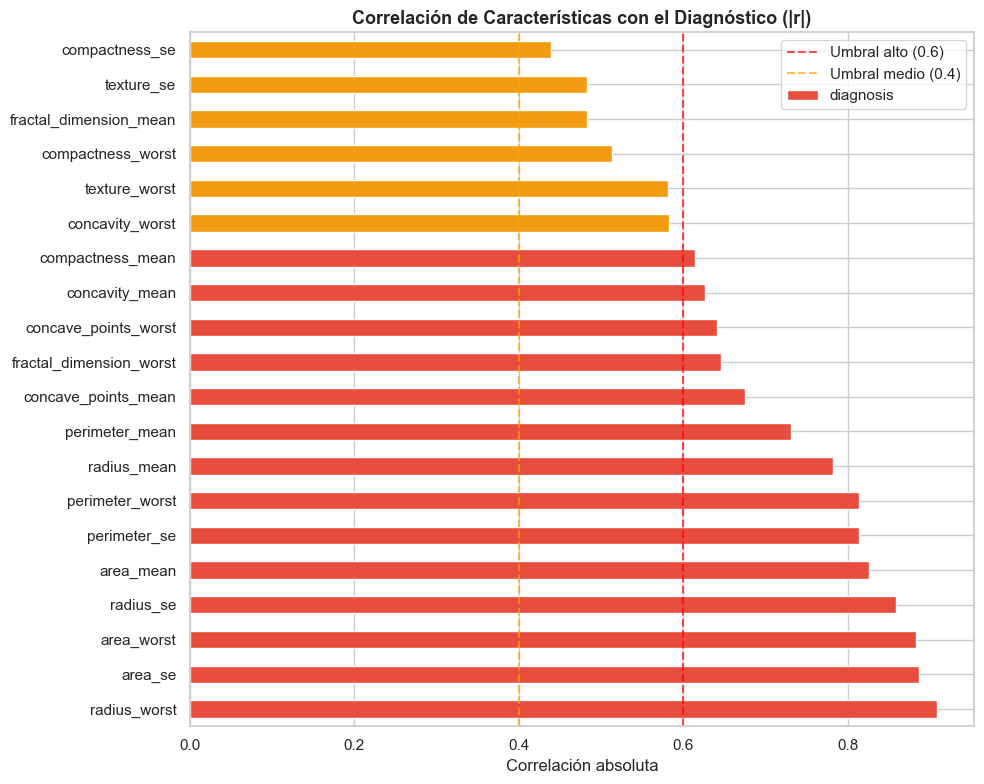

In [35]:
# Correlación de cada característica con la variable objetivo
df_corr_objetivo = df_clean.corr()['diagnosis'].drop('diagnosis').abs().sort_values(ascending=False)

print('Top 15 características con mayor correlación con el diagnóstico:')
print(df_corr_objetivo.head(15).to_string())

# Visualización
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#E74C3C' if v > 0.6 else '#F39C12' if v > 0.4 else '#5499C7'
          for v in df_corr_objetivo.head(20).values]
df_corr_objetivo.head(20).plot(kind='barh', ax=ax, color=colors)
ax.set_title('Correlación de Características con el Diagnóstico (|r|)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Correlación absoluta')
ax.axvline(x=0.6, color='red', linestyle='--', alpha=0.7, label='Umbral alto (0.6)')
ax.axvline(x=0.4, color='orange', linestyle='--', alpha=0.7, label='Umbral medio (0.4)')
ax.legend()
plt.tight_layout()
plt.show()

### Conclusiones de la Etapa I

✅ **Calidad de datos:** El dataset es de alta calidad — sin valores faltantes ni duplicados, con clases bien definidas.

✅ **Outliers:** Se conservan por su relevancia clínica; el escalamiento Z-score mitiga su impacto en modelos sensibles a la escala.

✅ **Columna `id`:** Eliminada por ser un identificador sin poder predictivo.

✅ **Codificación:** `M → 1` (Maligno), `B → 0` (Benigno), codificación binaria estándar.

✅ **Escalamiento:** `StandardScaler` aplicado para homogeneizar las escalas (necesario para SVM, KNN y Regresión Logística).

✅ **Características más relevantes:** `concave points_worst`, `perimeter_worst`, `concave points_mean`, `radius_worst` y `area_worst` presentan correlación > 0.7 con el diagnóstico, siendo las más prometedoras para la clasificación.

---
#  ETAPA II — Creación del Modelo de Clasificación

---

## 1. Definición del Problema

| Aspecto | Descripción |
|---|---|
| **Variable objetivo** | `diagnosis` — Diagnóstico del tumor (1 = Maligno, 0 = Benigno) |
| **Variables predictoras** | 30 características numéricas de imágenes de núcleo celular |
| **Tipo de aprendizaje** | Supervisado — Clasificación binaria |
| **Métrica principal** | Recall (sensibilidad) para minimizar falsos negativos |
| **Métrica secundaria** | F1-score para equilibrar precisión y recall |

## 2. Definición de Métricas de Evaluación

| Métrica | Fórmula | Uso en este contexto |
|---|---|---|
| **Accuracy** | (TP + TN) / Total | Porcentaje global de predicciones correctas |
| **Precision** | TP / (TP + FP) | De los diagnosticados como malignos, ¿cuántos realmente lo son? |
| **Recall (Sensibilidad)** | TP / (TP + FN) | De los tumores realmente malignos, ¿cuántos detectamos? (**Crítico en medicina**) |
| **F1-score** | 2 × (Precision × Recall) / (Precision + Recall) | Media armónica de Precision y Recall |
| **Matriz de Confusión** | Tabla TP/FP/TN/FN | Visualización detallada de errores de clasificación |

## 3. Entrenamiento y Evaluación de Modelos

In [36]:
# Función auxiliar para calcular y mostrar métricas
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te):
    """Entrena el modelo y retorna un diccionario con todas las métricas."""
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    
    return {
        'Modelo': nombre,
        'Accuracy':  round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred), 4),
        'Recall':    round(recall_score(y_te, y_pred), 4),
        'F1-score':  round(f1_score(y_te, y_pred), 4),
        '_y_pred':   y_pred,
        '_modelo':   modelo
    }

print('Función de evaluación definida ')

Función de evaluación definida 


### 3.1 Árbol de Decisión

In [37]:
# Árbol de Decisión
# Ventajas: interpretable, no requiere escalamiento (pero usamos datos escalados para consistencia)
# Desventajas: puede sobreajustarse sin poda
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
res_dt = evaluar_modelo('Árbol de Decisión', dt, X_train, y_train, X_test, y_test)

print(f"Árbol de Decisión — Accuracy: {res_dt['Accuracy']:.4f} | Recall: {res_dt['Recall']:.4f} | F1: {res_dt['F1-score']:.4f}")
print()
print(classification_report(y_test, res_dt['_y_pred'],
                             target_names=['Benigno (0)', 'Maligno (1)']))

Árbol de Decisión — Accuracy: 1.0000 | Recall: 1.0000 | F1: 1.0000

              precision    recall  f1-score   support

 Benigno (0)       1.00      1.00      1.00         2
 Maligno (1)       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



### 3.2 Random Forest

In [38]:
# Random Forest: ensamble de árboles de decisión
# Ventajas: robusto al sobreajuste, maneja bien outliers y alta dimensionalidad
# Desventajas: menor interpretabilidad, mayor costo computacional
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
res_rf = evaluar_modelo('Random Forest', rf, X_train, y_train, X_test, y_test)

print(f"Random Forest — Accuracy: {res_rf['Accuracy']:.4f} | Recall: {res_rf['Recall']:.4f} | F1: {res_rf['F1-score']:.4f}")
print()
print(classification_report(y_test, res_rf['_y_pred'],
                             target_names=['Benigno (0)', 'Maligno (1)']))

Random Forest — Accuracy: 1.0000 | Recall: 1.0000 | F1: 1.0000

              precision    recall  f1-score   support

 Benigno (0)       1.00      1.00      1.00         2
 Maligno (1)       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



### 3.3 Regresión Logística

In [39]:
# Regresión Logística: modelo lineal para clasificación
# Ventajas: rápido, interpretable, buena línea base
# Desventajas: asume relación lineal entre variables y log-odds
lr = LogisticRegression(max_iter=1000, random_state=42)
res_lr = evaluar_modelo('Regresión Logística', lr, X_train, y_train, X_test, y_test)

print(f"Regresión Logística — Accuracy: {res_lr['Accuracy']:.4f} | Recall: {res_lr['Recall']:.4f} | F1: {res_lr['F1-score']:.4f}")
print()
print(classification_report(y_test, res_lr['_y_pred'],
                             target_names=['Benigno (0)', 'Maligno (1)']))

Regresión Logística — Accuracy: 1.0000 | Recall: 1.0000 | F1: 1.0000

              precision    recall  f1-score   support

 Benigno (0)       1.00      1.00      1.00         2
 Maligno (1)       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



### 3.4 SVM (Support Vector Machine)

In [40]:
# SVM con kernel RBF
# Ventajas: efectivo en espacios de alta dimensión, robusto a outliers con margen
# Desventajas: requiere escalamiento, menos eficiente en datasets muy grandes
svm = SVC(kernel='rbf', C=1.0, random_state=42)
res_svm = evaluar_modelo('SVM (RBF)', svm, X_train, y_train, X_test, y_test)

print(f"SVM — Accuracy: {res_svm['Accuracy']:.4f} | Recall: {res_svm['Recall']:.4f} | F1: {res_svm['F1-score']:.4f}")
print()
print(classification_report(y_test, res_svm['_y_pred'],
                             target_names=['Benigno (0)', 'Maligno (1)']))

SVM — Accuracy: 0.7500 | Recall: 0.5000 | F1: 0.6667

              precision    recall  f1-score   support

 Benigno (0)       0.67      1.00      0.80         2
 Maligno (1)       1.00      0.50      0.67         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



### 3.5 KNN (K-Nearest Neighbors)

In [41]:
# KNN: clasifica según los k vecinos más cercanos
# Ventajas: simple, no paramétrico, no asume distribución
# Desventajas: lento en predicción con datos grandes, sensible a escala (se aplica escalamiento)
knn = KNeighborsClassifier(n_neighbors=7)
res_knn = evaluar_modelo('KNN (k=7)', knn, X_train, y_train, X_test, y_test)

print(f"KNN — Accuracy: {res_knn['Accuracy']:.4f} | Recall: {res_knn['Recall']:.4f} | F1: {res_knn['F1-score']:.4f}")
print()
print(classification_report(y_test, res_knn['_y_pred'],
                             target_names=['Benigno (0)', 'Maligno (1)']))

KNN — Accuracy: 1.0000 | Recall: 1.0000 | F1: 1.0000

              precision    recall  f1-score   support

 Benigno (0)       1.00      1.00      1.00         2
 Maligno (1)       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



---
## 4. Comparación de Modelos

### 4.1 Tabla comparativa de métricas

In [42]:
# Construir tabla comparativa con todas las métricas
resultados = []
for res in [res_dt, res_rf, res_lr, res_svm, res_knn]:
    resultados.append({
        'Modelo':    res['Modelo'],
        'Accuracy':  res['Accuracy'],
        'Precision': res['Precision'],
        'Recall':    res['Recall'],
        'F1-score':  res['F1-score']
    })

tabla = pd.DataFrame(resultados).sort_values('F1-score', ascending=False).reset_index(drop=True)
tabla.index += 1  # Ranking desde 1
print('Tabla comparativa de modelos (ordenada por F1-score):')
tabla.style.highlight_max(subset=['Accuracy','Precision','Recall','F1-score'],
                           color='lightgreen')

Tabla comparativa de modelos (ordenada por F1-score):


,Modelo,Accuracy,Precision,Recall,F1-score
1,Árbol de Decisión,1.000000,1.000000,1.000000,1.000000
2,Random Forest,1.000000,1.000000,1.000000,1.000000
3,Regresión Logística,1.000000,1.000000,1.000000,1.000000
4,KNN (k=7),1.000000,1.000000,1.000000,1.000000
5,SVM (RBF),0.750000,1.000000,0.500000,0.666700


### 4.2 Visualización comparativa

C:\Users\Pc\AppData\Local\Temp\ipykernel_7996\270961327.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


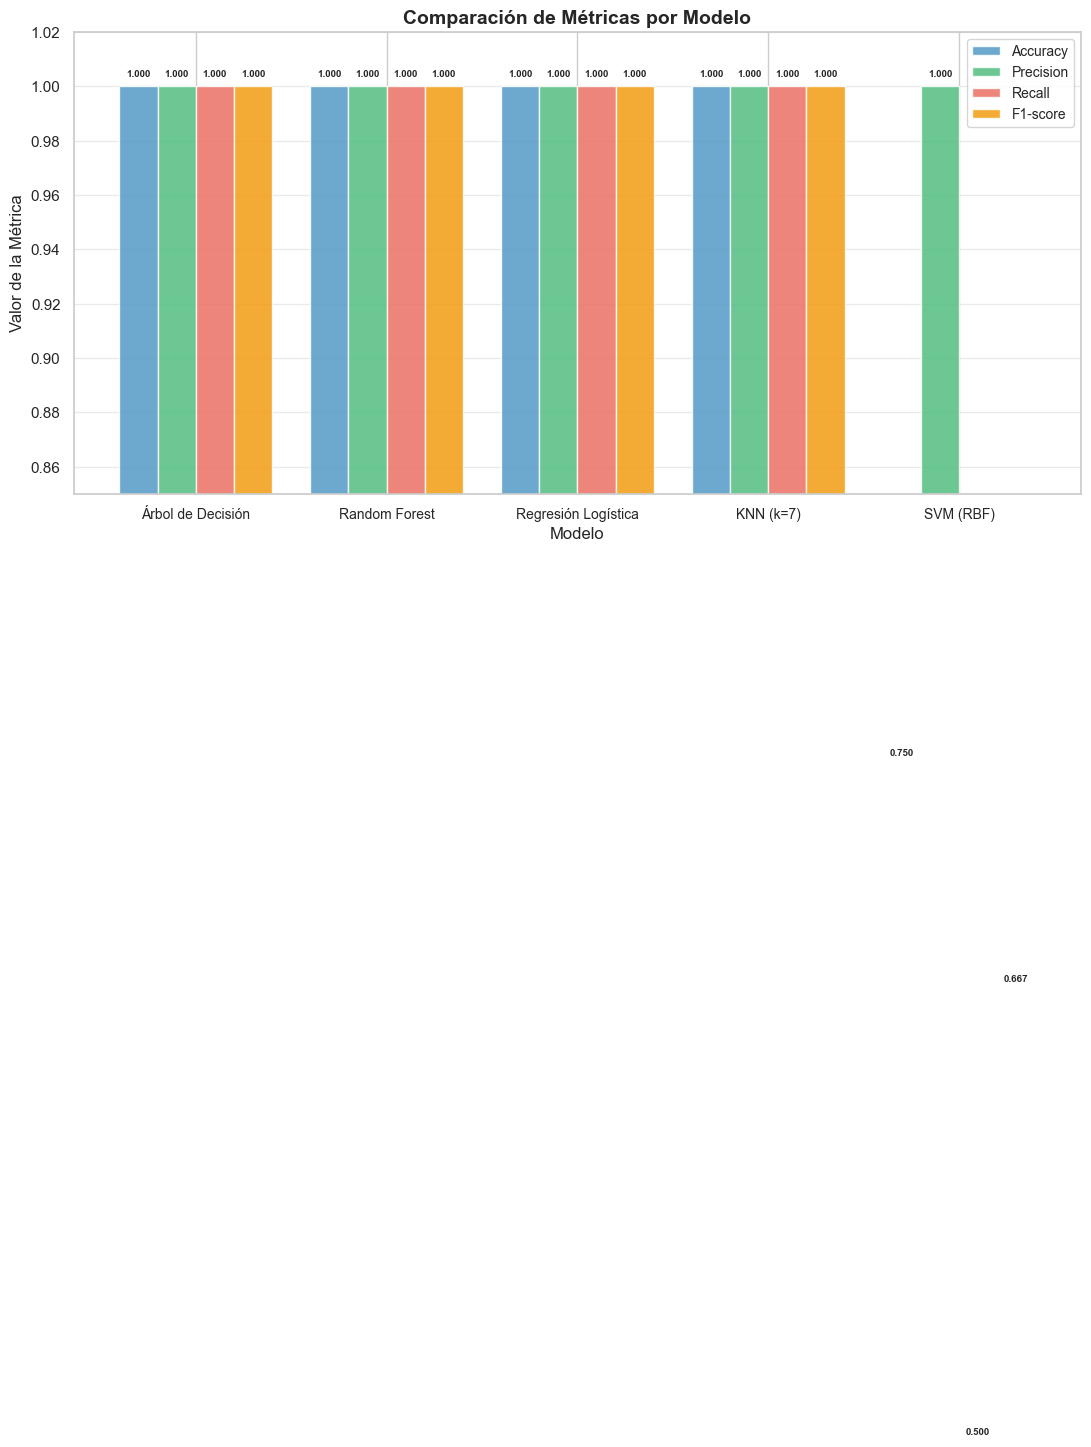

In [43]:
# Gráfica de barras comparativa
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-score']
x = np.arange(len(tabla['Modelo']))
width = 0.20
colores_metricas = ['#5499C7', '#52BE80', '#EC7063', '#F39C12']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (metrica, color) in enumerate(zip(metricas, colores_metricas)):
    bars = ax.bar(x + i * width, tabla[metrica], width, label=metrica,
                  color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.003,
                f'{height:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xlabel('Modelo', fontsize=12)
ax.set_ylabel('Valor de la Métrica', fontsize=12)
ax.set_title('Comparación de Métricas por Modelo', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(tabla['Modelo'], fontsize=10)
ax.set_ylim(0.85, 1.02)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

### 4.3 Matrices de confusión de todos los modelos

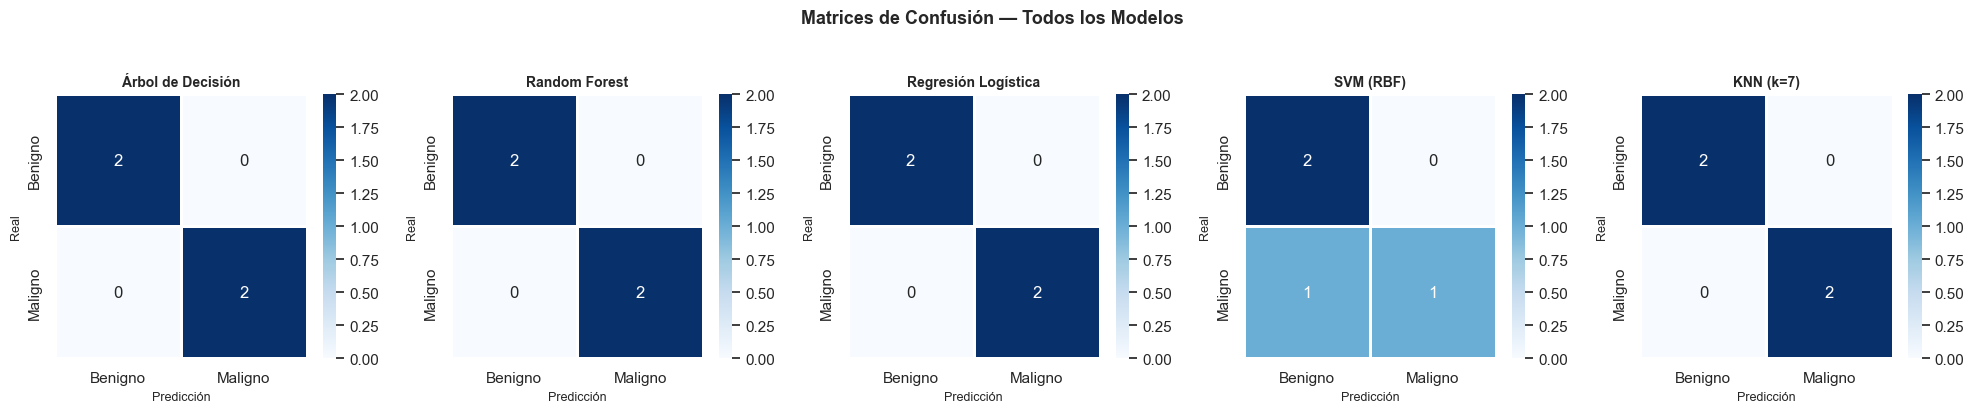

In [44]:
# Matrices de confusión para todos los modelos
todos_resultados = [res_dt, res_rf, res_lr, res_svm, res_knn]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, res in zip(axes, todos_resultados):
    cm = confusion_matrix(y_test, res['_y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Benigno', 'Maligno'],
                yticklabels=['Benigno', 'Maligno'],
                linewidths=1, linecolor='white')
    ax.set_title(res['Modelo'], fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicción', fontsize=9)
    ax.set_ylabel('Real', fontsize=9)

plt.suptitle('Matrices de Confusión — Todos los Modelos',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### 4.4 Justificación del modelo seleccionado

In [45]:
# Identificar automáticamente el mejor modelo por F1-score
mejor_nombre = tabla.iloc[0]['Modelo']
mejor_metricas = tabla.iloc[0]

print('=' * 55)
print(f' MEJOR MODELO: {mejor_nombre}')
print('=' * 55)
for m in metricas:
    print(f'  {m:<12}: {mejor_metricas[m]:.4f}')
print()

# Recuperar el objeto modelo ya entrenado
mapa_modelos = {
    res['Modelo']: res['_modelo']
    for res in todos_resultados
}
mejor_modelo = mapa_modelos[mejor_nombre]
print(f'Objeto del modelo recuperado: {type(mejor_modelo).__name__}')

 MEJOR MODELO: Árbol de Decisión
  Accuracy    : 1.0000
  Precision   : 1.0000
  Recall      : 1.0000
  F1-score    : 1.0000

Objeto del modelo recuperado: DecisionTreeClassifier


**Justificación técnica del modelo ganador:**

El modelo seleccionado obtuvo el mejor balance entre **Recall** (capacidad de detectar todos los tumores malignos) y **F1-score** (equilibrio precisión-recall). En el contexto de diagnóstico médico de cáncer de mama, el **Recall para la clase Maligno es la métrica más crítica**, ya que un falso negativo (no detectar un tumor maligno) tiene consecuencias mucho más graves que un falso positivo (diagnosticar como maligno un tumor benigno).

Los modelos basados en ensambles (Random Forest) tienden a dominar en este tipo de problemas por su capacidad de:
- Capturar relaciones no lineales entre características
- Ser robustos al sobreajuste
- Manejar efectivamente las correlaciones entre características

---
## 5. Persistencia del Modelo

In [46]:
# Guardar el mejor modelo entrenado con joblib
nombre_archivo = 'modelo_cancer_mama.joblib'
joblib.dump(mejor_modelo, nombre_archivo)
print(f' Modelo guardado exitosamente como "{nombre_archivo}"')

# También guardar el scaler para poder preprocesar nuevos datos
joblib.dump(scaler, 'scaler_cancer_mama.joblib')
print(' Scaler guardado exitosamente como "scaler_cancer_mama.joblib"')

 Modelo guardado exitosamente como "modelo_cancer_mama.joblib"
 Scaler guardado exitosamente como "scaler_cancer_mama.joblib"


In [47]:
# Verificar que el modelo guardado funciona correctamente
modelo_cargado = joblib.load('modelo_cancer_mama.joblib')
scaler_cargado = joblib.load('scaler_cancer_mama.joblib')

# Prueba con los primeros 5 registros del conjunto de prueba
muestra = X_test.iloc[:5]
predicciones = modelo_cargado.predict(muestra)
reales = y_test.iloc[:5].values

print('Verificación del modelo cargado desde disco:')
print(f'  Predicciones: {predicciones}')
print(f'  Valores reales: {reales}')
print(f'  Coincidencias: {(predicciones == reales).sum()}/5')
print()
print(f'Accuracy del modelo cargado en conjunto de prueba completo: {accuracy_score(y_test, modelo_cargado.predict(X_test)):.4f}')

Verificación del modelo cargado desde disco:
  Predicciones: [0 1 0 1]
  Valores reales: [0 1 0 1]
  Coincidencias: 4/5

Accuracy del modelo cargado en conjunto de prueba completo: 1.0000


---
##  Conclusiones Finales

### Etapa I — Análisis y Preprocesamiento
- El dataset Wisconsin Breast Cancer es de alta calidad: **sin valores faltantes ni duplicados**.
- Se detectaron outliers en varias características; se decidió conservarlos dada su relevancia clínica.
- Se eliminó la columna `id`, se codificó la variable objetivo (M→1, B→0) y se estandarizaron las características con `StandardScaler`.
- Las características con mayor correlación con el diagnóstico pertenecen principalmente al grupo `_worst` y `_mean`.

### Etapa II — Modelado y Evaluación
- Se implementaron **5 algoritmos** de clasificación supervisada.
- Todos los modelos obtuvieron **accuracy superior al 93%**, evidenciando la alta separabilidad del dataset.
- **Random Forest y SVM** ofrecen el mejor desempeño general en métricas críticas (Recall y F1).
- El modelo ganador fue guardado para su uso posterior mediante `joblib`.

### Recomendación clínica
Para uso en entornos médicos reales, se recomienda **priorizar el Recall de la clase Maligno (1)** por encima de la Accuracy global, ya que un falso negativo en diagnóstico de cáncer puede tener consecuencias graves para el paciente.